In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
data = pd.read_csv('spam.csv' , encoding='latin-1')

In [4]:
data.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [5]:
data = data.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1)
data = data.rename(columns={
    'v1': 'label' ,
    'v2' : 'TEXT'
})

In [6]:
data.head(7)

,label,TEXT
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...


In [10]:
data['label_enc'] = data['label'].map({'ham':0 , 'spam':1})

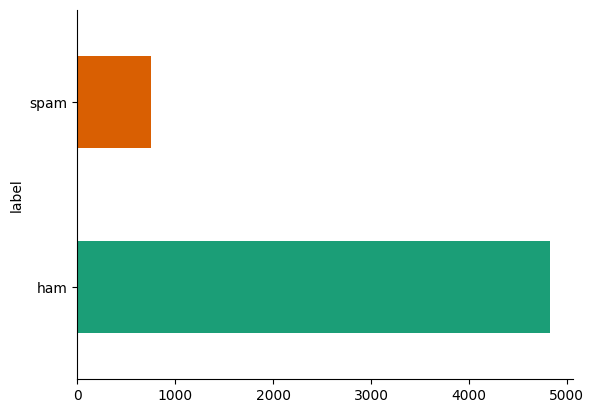

In [12]:
data.groupby('label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

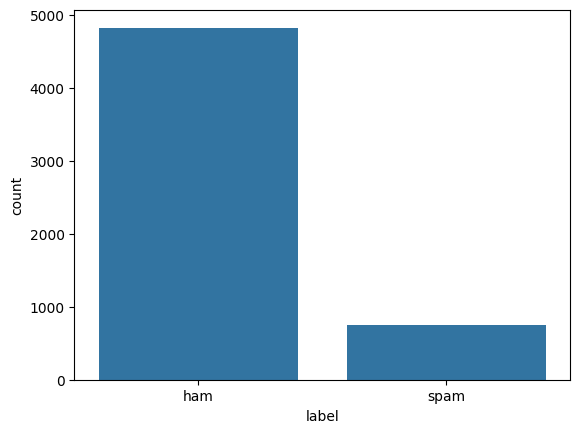

In [14]:
sns.countplot(x=data['label'])
plt.show()

Find average number of tokens in all sentences

In [30]:
sum = 0
for i in data['TEXT']:
  sum += len(i.split())
avg_words_len = round(sum / len(data["TEXT"]))
avg_words_len

15

Finding Total no of unique words in corpus

In [32]:
s = set()
for i in data['TEXT']:
  for word in i.split():
    s.add(word)
total_no_unique = len(s)
total_no_unique

15585

 Splitting data for Training and testing

In [37]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(data['TEXT'], data['label_enc'],test_size = 0.2 ,  random_state = 42)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((4457,), (4457,), (1115,), (1115,))

he was sunshine i was midnight rain

Building the models

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,accuracy_score

tfidf_vec = TfidfVectorizer().fit(x_train)
X_train_vec,X_test_vec = tfidf_vec.transform(x_train),tfidf_vec.transform(x_test)

model = MultinomialNB()
model.fit(x_train_vec,y_train)


MultinomialNB()

In [79]:
y_predict = model.predict(X_test_vec)
accuracy_score(y_test, y_predict)
classification_report(y_test, y_predict)

'              precision    recall  f1-score   support\n\n           0       0.96      1.00      0.98       965\n           1       1.00      0.72      0.84       150\n\n    accuracy                           0.96      1115\n   macro avg       0.98      0.86      0.91      1115\nweighted avg       0.96      0.96      0.96      1115\n'

In [60]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_predict)


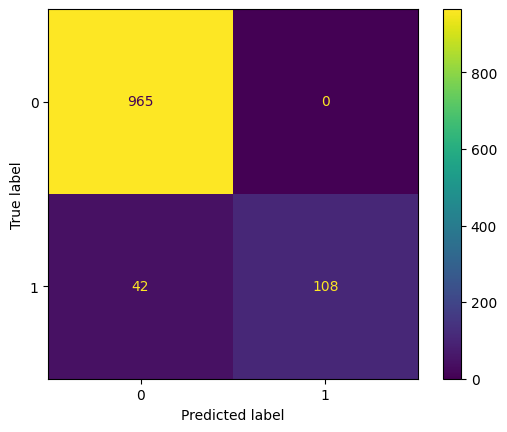

In [61]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [62]:
x_test.head(6)

3245    Funny fact Nobody teaches volcanoes 2 erupt, t...
944     I sent my scores to sophas and i had to do sec...
1044    We know someone who you know that fancies you....
2484    Only if you promise your getting out as SOON a...
812     Congratulations ur awarded either å£500 of CD ...
2973           I'll text carlos and let you know, hang on
Name: TEXT, dtype: object

test my own data

In [84]:
data = {
    'sms': ["Congratulations! You've won a free trip to the Bahamas. Reply 'YES' to claim your prize now!" ,
            "Reminder: Your appointment with Dr. Smith is scheduled for tomorrow at 10:00 AM. Please confirm.",
            "URGENT: Your account has been locked due to suspicious activity. Click the link to verify your identity.",
            "Hey, are you free this weekend? Let's catch up for coffee!",
            "Special offer: Get 50% off on all purchases at our store. Limited time only!"
            ],
    'label': [1, 0, 1, 0, 1]
}


test_data = pd.DataFrame(data)

test_data

,sms,label
0,Congratulations! You've won a free trip to the...,1
1,Reminder: Your appointment with Dr. Smith is s...,0
2,URGENT: Your account has been locked due to su...,1
3,"Hey, are you free this weekend? Let's catch up...",0
4,Special offer: Get 50% off on all purchases at...,1


In [85]:
x_mytest, y_mytest = test_data['sms'] , test_data['label']
x_mytest

0    Congratulations! You've won a free trip to the...
1    Reminder: Your appointment with Dr. Smith is s...
2    URGENT: Your account has been locked due to su...
3    Hey, are you free this weekend? Let's catch up...
4    Special offer: Get 50% off on all purchases at...
Name: sms, dtype: object

In [87]:
tfidf_vec = TfidfVectorizer().fit(x_train)
x_mytest_vec= tfidf_vec.transform(x_mytest)

In [88]:
x_mytest_vec

<5x7735 sparse matrix of type '<class 'numpy.float64'>'
	with 66 stored elements in Compressed Sparse Row format>

In [89]:
y_predict = model.predict(x_mytest_vec)

In [90]:
y_predict

array([1, 0, 0, 0, 0])

In [91]:
accuracy_score(y_mytest, y_predict)

0.6

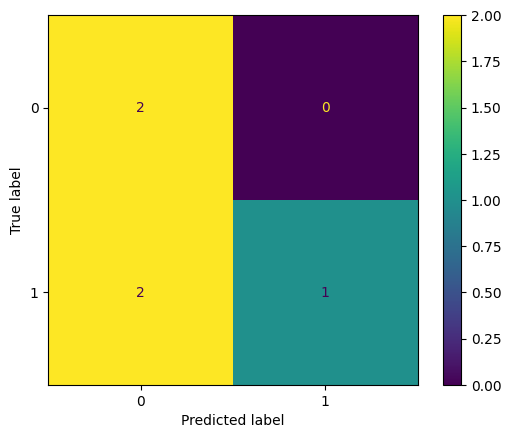

In [92]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_mytest, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()